# Young stand demo (NYSKOG + Näslund 1986)


## Notebook Objectives
- Build a young stand workflow from initialization through growth with reproducible inputs.
- Provide runnable, copy-safe snippets that work in the docs build environment.

## Prerequisites
- Python environment with `pyforestry` installed from this repository.
- Execute cells in order; random components should use fixed seeds where shown.

## Sources
- NYSKOG reconstruction and Swedish growth utilities in `pyforestry.sweden.adapters`.
- Näslund (1986) height/diameter relationships where used in the workflow.


This notebook shows a small, reproducible workflow for constructing a Swedish site,
reconstructing a young stand using the NYSKOG equations (Appendix 2), and running
a short forward simulation with the young-stand equations and Näslund damage model.

**Note:** The original HUGIN/NYSKOG database is not part of pyforestry, so this
demo synthesizes an initial tree list from the reconstruction equations only.


In [1]:
import copy
import math
import random

import matplotlib.pyplot as plt
import numpy as np

from pyforestry.base.helpers.primitives.sitebase import SiteBase
from pyforestry.base.helpers.tree import Tree
from pyforestry.base.helpers.tree_species import TreeSpecies
from pyforestry.sweden.adapters.elfving_1982 import (
    HuginMeanHeightModel,
    NfiRegion,
    NyskogReconstruction,
    RegenerationType,
    nyskog_indicators_from_site,
)
from pyforestry.sweden.mortality.naslund_1986 import (
    Naslund1986DamageModel,
    SaplingSpeciesGroup,
)
from pyforestry.sweden.systems.nystrom_soderberg_1987 import NystromSoderberg1987
from pyforestry.sweden.site import Sweden, SwedishSite
from pyforestry.sweden.siteindex.sis.generated_site_category_trees import (
    predict_site_categories_county_tree,
)
from pyforestry.sweden.siteindex.sis.hagglund_lundmark_1977 import Hagglund_Lundmark_1977_SIS


class SwedishSiteDemo(SwedishSite):
    """Concrete wrapper for notebooks (implements SiteBase abstract method)."""

    def compute_attributes(self) -> None:
        SwedishSite.__post_init__(self)

    def __post_init__(self) -> None:
        SiteBase.__post_init__(self)


random.seed(42)
np.random.seed(42)


## 1. Define a Swedish site


In [2]:
site_index_pine_m = 20.0
site_index_spruce_m = 22.0
county = Sweden.County.KOPPARBERG_OVRIGA
site_category_species = "Pinus sylvestris"
requested_sis = site_index_pine_m

predicted_site_categories = predict_site_categories_county_tree(
    sis_hagglund_1979=requested_sis,
    species=site_category_species,
    Direktlan=county,
)

site = SwedishSiteDemo(
    latitude=60.5,
    longitude=15.0,
    altitude=150.0,
    field_layer=predicted_site_categories["field_layer"],
    bottom_layer=predicted_site_categories["bottom_layer"],
    soil_texture=predicted_site_categories["soil_texture"],
    soil_moisture=predicted_site_categories["soil_moisture"],
    soil_depth=predicted_site_categories["soil_depth"],
    soil_water=predicted_site_categories["soil_water"],
    ditched=predicted_site_categories["ditched"],
)

achieved_sis = Hagglund_Lundmark_1977_SIS(
    species=site_category_species,
    latitude=site.latitude,
    altitude=site.altitude or 0.0,
    soil_moisture=site.soil_moisture,
    ground_layer=site.bottom_layer or Sweden.BottomLayer.FRESH_MOSS,
    vegetation=site.field_layer,
    soil_texture=site.soil_texture or Sweden.SoilTextureTill.SANDY,
    climate_code=site.climate_zone or Sweden.ClimateZone.K1,
    lateral_water=site.soil_water or Sweden.SoilWater.SELDOM_NEVER,
    soil_depth=site.soil_depth or Sweden.SoilDepth.DEEP,
    incline_percent=site.incline_percent or 0.0,
    aspect=site.aspect or 0.0,
    nfi_adjustments=True,
    dlan=site.county or county,
    ditched=bool(site.ditched),
    peat=False,
    gotland=False,
    coast=(site.distance_to_coast or 9999.0) < 50.0,
    limes_norrlandicus=bool(site.n_of_limes_norrlandicus),
)

sis_closeness = {
    "requested_sis": requested_sis,
    "achieved_sis": float(achieved_sis),
    "sis_abs_error": abs(float(achieved_sis) - requested_sis),
    "sis_rel_error_pct": 100.0 * abs(float(achieved_sis) - requested_sis) / requested_sis,
}

display({"sis_closeness": sis_closeness, "predicted_site_categories": predicted_site_categories})
site

{'sis_closeness': {'requested_sis': 20.0,
  'achieved_sis': 20.698654683125625,
  'sis_abs_error': 0.6986546831256248,
  'sis_rel_error_pct': 3.493273415628124},
 'predicted_site_categories': {'field_layer': <SwedenFieldLayer.LICHEN_FREQUENT: Vegetation(code=17, swedish_name='Lavrik', english_name='Lichen, frequent occurrence', index=-0.5)>,
  'bottom_layer': <SwedenBottomLayer.BOGMOSS_TYPE: BottomLayerType(code=4, english_name='Bogmoss type (Sphagnum)', swedish_name='Vitmosstyp')>,
  'soil_texture': <SwedenSoilTextureTill.SANDY_MOIG: SoilTextureCategory(code=4, swedish_name='Sandig-moig morän', english_name='Sandy-silty till', short_name='Medium sand')>,
  'soil_moisture': <SwedenSoilMoisture.MESIC: SoilMoistureData(code=2, swedish_description='frisk', english_description='Mesic (subsoil water depth = 1-2 m)')>,
  'soil_depth': <SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcro

SwedishSiteDemo(latitude=60.5, longitude=15.0, altitude=150.0, field_layer=<SwedenFieldLayer.LICHEN_FREQUENT: Vegetation(code=17, swedish_name='Lavrik', english_name='Lichen, frequent occurrence', index=-0.5)>, bottom_layer=<SwedenBottomLayer.BOGMOSS_TYPE: BottomLayerType(code=4, english_name='Bogmoss type (Sphagnum)', swedish_name='Vitmosstyp')>, soil_texture=<SwedenSoilTextureTill.SANDY_MOIG: SoilTextureCategory(code=4, swedish_name='Sandig-moig morän', english_name='Sandy-silty till', short_name='Medium sand')>, soil_moisture=<SwedenSoilMoisture.MESIC: SoilMoistureData(code=2, swedish_description='frisk', english_description='Mesic (subsoil water depth = 1-2 m)')>, soil_depth=<SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcrops.')>, soil_water=<SwedenSoilWater.SHORTER_PERIODS: SoilWaterCat(code=2, swedish_description='kortare perioder', english_description='Shorter periods')>

## 2. Reconstruct a young stand using NYSKOG equations


In [3]:
regen_type = RegenerationType.NATURAL
species_to_plant = TreeSpecies.Sweden.pinus_sylvestris
nfi_region = NfiRegion.REG3

age_years = 12.0

mean_height_main_m = HuginMeanHeightModel.mean_height(
    age_years=age_years,
    species=species_to_plant,
    site_index_pine_m=site_index_pine_m,
    site_index_spruce_m=site_index_spruce_m,
)

indicators = nyskog_indicators_from_site(
    field_layer=site.field_layer,
    soil_moisture=site.soil_moisture,
)

# NOTE: ASINW is typically derived from the published Elfving regeneration functions (Appendix 2).
asinw = 110.0
q = NyskogReconstruction.production_potential_q(asinw)
ln_q = math.log(q)
ln_si = math.log(site_index_pine_m)

under_dimension_prob = NyskogReconstruction.udim_probability(q)
height_indicator_dm = max(15.0, 10.0 * mean_height_main_m)

stem_total = NyskogReconstruction.total_stems(
    regeneration_type=regen_type,
    mean_height_main_m=mean_height_main_m,
    q=q,
    ln_q=ln_q,
    ln_si=ln_si,
    under_dimension_prob=under_dimension_prob,
    wet=indicators["wet"],
    dry=indicators["dry"],
    height_indicator_dm=height_indicator_dm,
    deterministic=True,
)

prop_conifer = NyskogReconstruction.proportion_conifer(
    regeneration_type=regen_type,
    q=q,
    ln_qind=ln_q,
    stem_total=stem_total,
    ln_si=ln_si,
    wet=indicators["wet"],
    dry=indicators["dry"],
    rich=indicators["rich"],
    poor=indicators["poor"],
    deterministic=True,
)

prop_dom_conifer = NyskogReconstruction.dominant_conifer_share(
    regeneration_type=regen_type,
    qind=q,
    ln_si=ln_si,
    wet=indicators["wet"],
    dry=indicators["dry"],
    rich=indicators["rich"],
    poor=indicators["poor"],
    hwod=indicators["hwod"],
    hwd=indicators["hwd"],
    shrubs=indicators["shrubs"],
    lichen=indicators["lichen"],
    deterministic=True,
)

stems = NyskogReconstruction.stems_per_species(
    regeneration_type=regen_type,
    species_to_plant=species_to_plant,
    stem_total=stem_total,
    prop_conifer=prop_conifer,
    prop_dom_conifer=prop_dom_conifer,
    site_index_m=site_index_pine_m,
    nfi_region=nfi_region,
)

stems


{'pine': 1.1237727333829194e-08,
 'spruce': 2.7121535622305318e-05,
 'contorta': 0.0,
 'larch': 0.0,
 'birch': 4.107623694305894,
 'other_broadleaf': 0.1711509872627456}

## 3. Sample a tree list from reconstructed stand metrics


In [4]:
def mean_height_secondary(species: TreeSpecies) -> float:
    site_index_m = site_index_spruce_m if species in {
        TreeSpecies.Sweden.picea_abies,
        TreeSpecies.Sweden.picea_sitchensis,
        TreeSpecies.Sweden.picea_mariana,
    } else site_index_pine_m

    return NyskogReconstruction.secondary_mean_height(
        regeneration_type=regen_type,
        secondary_species=species,
        site_index_m=site_index_m,
        mean_height_main_m=mean_height_main_m,
        herb=indicators["herb"],
        dry=indicators["dry"],
        wet=indicators["wet"],
        deterministic=True,
    )


species_map = {
    "pine": TreeSpecies.Sweden.pinus_sylvestris,
    "spruce": TreeSpecies.Sweden.picea_abies,
    "contorta": TreeSpecies.Sweden.pinus_contorta,
    "larch": TreeSpecies.Sweden.larix_sibirica,
    "birch": TreeSpecies.Sweden.betula_pendula,
    "other_broadleaf": TreeSpecies.Sweden.populus_tremula,
}

mean_heights = {
    "pine": mean_height_main_m,
    "spruce": mean_height_secondary(TreeSpecies.Sweden.picea_abies),
    "contorta": mean_height_secondary(TreeSpecies.Sweden.pinus_contorta),
    "larch": mean_height_secondary(TreeSpecies.Sweden.larix_sibirica),
    "birch": mean_height_secondary(TreeSpecies.Sweden.betula_pendula),
    "other_broadleaf": mean_height_secondary(TreeSpecies.Sweden.populus_tremula),
}

sample_n = 200
total_stems = sum(stems.values())
trees: list[Tree] = []

for label, stems_per_ha in stems.items():
    if stems_per_ha <= 0.0:
        continue
    share = stems_per_ha / total_stems
    n_trees = max(1, int(round(sample_n * share)))

    species = species_map[label]
    mean_height = mean_heights[label]
    cvh = NyskogReconstruction.height_variation(
        species=species,
        species_height_m=mean_height,
        q=q,
        ln_q=ln_q,
        self_rejuvenated=1,
        deterministic=True,
    )
    beta, shape = NyskogReconstruction.weibull_parameters(
        species=species,
        cvh=cvh,
        mean_height_m=mean_height,
    )

    heights = beta * np.random.weibull(shape, size=n_trees)
    weight = stems_per_ha / n_trees

    for height in heights:
        trees.append(
            Tree(
                species=species,
                height_m=float(height),
                weight_n=weight,
            )
        )

base_trees = copy.deepcopy(trees)

len(trees)


202

## 4. DBH and Näslund damage proportions


In [5]:
def stand_metrics(tree_list: list[Tree]) -> dict[str, float]:
    heights = np.array([t.height_m or 0.0 for t in tree_list])
    weights = np.array([t.weight_n or 0.0 for t in tree_list])
    total_weight = weights.sum()
    if total_weight <= 0.0:
        return {
            "mean_height_m": 0.0,
            "total_height_sqr_m2_per_100m2": 0.0,
            "broadleaf_height_sqr_share": 0.0,
            "h_max_m": 0.0,
        }
    mean_height = float((heights * weights).sum() / total_weight)

    height_sqr_sum = float(((heights**2) * weights).sum())
    total_height_sqr_m2_per_100m2 = height_sqr_sum * 0.01

    broadleaf_species = {
        TreeSpecies.Sweden.betula_pendula,
        TreeSpecies.Sweden.betula_pubescens,
        TreeSpecies.Sweden.populus_tremula,
    }
    broadleaf_mask = np.array([t.species in broadleaf_species for t in tree_list])
    broadleaf_sqr_sum = float(((heights**2) * weights * broadleaf_mask).sum())
    if height_sqr_sum > 0.0:
        broadleaf_share = broadleaf_sqr_sum / height_sqr_sum
    else:
        broadleaf_share = 0.0

    top_heights = sorted(heights, reverse=True)[:3]
    h_max_m = float(np.mean(top_heights)) if top_heights else 0.0

    return {
        "mean_height_m": mean_height,
        "total_height_sqr_m2_per_100m2": total_height_sqr_m2_per_100m2,
        "broadleaf_height_sqr_share": broadleaf_share,
        "h_max_m": h_max_m,
    }


def sapling_group(species: TreeSpecies) -> SaplingSpeciesGroup:
    if species in {
        TreeSpecies.Sweden.pinus_sylvestris,
        TreeSpecies.Sweden.larix_sibirica,
        TreeSpecies.Sweden.larix_decidua,
        TreeSpecies.Sweden.larix_europaea_x_leptolepis,
        TreeSpecies.Sweden.larix_sukaczewii,
    }:
        return SaplingSpeciesGroup.PINE
    if species == TreeSpecies.Sweden.pinus_contorta:
        return SaplingSpeciesGroup.CONTORTA
    if species == TreeSpecies.Sweden.picea_abies:
        return SaplingSpeciesGroup.SPRUCE
    if species in {
        TreeSpecies.Sweden.betula_pendula,
        TreeSpecies.Sweden.betula_pubescens,
    }:
        return SaplingSpeciesGroup.BIRCH
    if species in {
        TreeSpecies.Sweden.populus_tremula,
        TreeSpecies.Sweden.populus_tremula_x_tremuloides,
    }:
        return SaplingSpeciesGroup.ASPEN
    return SaplingSpeciesGroup.OTHER_BROADLEAF


def apply_dbh(tree_list: list[Tree]) -> None:
    metrics = stand_metrics(tree_list)
    if metrics["mean_height_m"] <= 0.0:
        return
    for tree in tree_list:
        if tree.height_m is None or tree.species is None:
            continue
        tree.diameter_cm = NystromSoderberg1987.dbh_from_height(
            height_dm=tree.height_m * 10.0,
            species=tree.species,
            total_height_sqr_m2_per_100m2=metrics["total_height_sqr_m2_per_100m2"],
            broadleaf_height_sqr_share=metrics["broadleaf_height_sqr_share"],
            natural_regeneration=1,
            cleaning_indicator=0,
            years_since_cleaning=0,
            altitude_m=site.altitude or 0.0,
            latitude_deg=site.latitude,
            shrubs=indicators["shrubs"],
            herb_grass=indicators["herb"],
            near_coast=1 if (site.distance_to_coast or 99.0) < 5.0 else 0,
            site_index_pine_m=site_index_pine_m,
            h_max_m=metrics["h_max_m"],
            veg=0,
        )


def damage_proportions(tree_list: list[Tree]) -> dict[SaplingSpeciesGroup, float]:
    stems = {sg: 0.0 for sg in SaplingSpeciesGroup}
    height_sums = {sg: 0.0 for sg in SaplingSpeciesGroup}

    for tree in tree_list:
        if tree.species is None or tree.height_m is None:
            continue
        group = sapling_group(tree.species)
        stems[group] += tree.weight_n or 0.0
        height_sums[group] += (tree.weight_n or 0.0) * tree.height_m

    mean_heights = {
        sg: (height_sums[sg] / stems[sg] if stems[sg] > 0.0 else 0.0)
        for sg in SaplingSpeciesGroup
    }

    return Naslund1986DamageModel.damage_proportions(
        stems=stems,
        mean_heights=mean_heights,
        site_index_pine_m=site_index_pine_m,
        site_index_spruce_m=site_index_spruce_m,
        latitude_deg=site.latitude,
        altitude_m=site.altitude or 0.0,
    )


def apply_damage_mortality(
    tree_list: list[Tree],
    damage_props: dict[SaplingSpeciesGroup, float],
) -> None:
    for tree in tree_list:
        if tree.species is None:
            continue
        group = sapling_group(tree.species)
        damage_prop = damage_props.get(group, 0.0)
        damage_prop = min(1.0, max(0.0, damage_prop))
        if tree.weight_n is not None:
            tree.weight_n *= 1.0 - damage_prop


apply_dbh(trees)
damage_proportions(trees)


{<SaplingSpeciesGroup.PINE: 'pine'>: 0.9210190958848993,
 <SaplingSpeciesGroup.SPRUCE: 'spruce'>: 0.31884692539203713,
 <SaplingSpeciesGroup.CONTORTA: 'contorta'>: 0.46655281692975714,
 <SaplingSpeciesGroup.BIRCH: 'birch'>: 0.43137552006404767,
 <SaplingSpeciesGroup.ASPEN: 'aspen'>: 0.808861286495369}

## 5. Simple forward simulation


In [6]:
def stand_summary(tree_list: list[Tree], age_years: float) -> dict[str, float]:
    heights = np.array([t.height_m or 0.0 for t in tree_list])
    diameters = np.array([t.diameter_cm or 0.0 for t in tree_list])
    weights = np.array([t.weight_n or 0.0 for t in tree_list])
    total_weight = weights.sum()
    if total_weight <= 0.0:
        return {
            "age_years": age_years,
            "mean_height_m": 0.0,
            "mean_dbh_cm": 0.0,
            "basal_area_m2_ha": 0.0,
            "stems_per_ha": 0.0,
            "pine_damage_prop": 0.0,
            "spruce_damage_prop": 0.0,
            "birch_damage_prop": 0.0,
        }
    mean_height = float((heights * weights).sum() / total_weight)
    mean_dbh = float((diameters * weights).sum() / total_weight)
    basal_area = float((math.pi * (diameters / 200.0) ** 2 * weights).sum())

    damages = damage_proportions(tree_list)

    return {
        "age_years": age_years,
        "mean_height_m": mean_height,
        "mean_dbh_cm": mean_dbh,
        "basal_area_m2_ha": basal_area,
        "stems_per_ha": float(total_weight),
        "pine_damage_prop": damages.get(SaplingSpeciesGroup.PINE, 0.0),
        "spruce_damage_prop": damages.get(SaplingSpeciesGroup.SPRUCE, 0.0),
        "birch_damage_prop": damages.get(SaplingSpeciesGroup.BIRCH, 0.0),
    }


def advance_years(tree_list: list[Tree], age_years: float, dt: float) -> float:
    current_mean_height = stand_metrics(tree_list)["mean_height_m"]
    new_mean_height = HuginMeanHeightModel.mean_height(
        age_years=age_years + dt,
        species=species_to_plant,
        site_index_pine_m=site_index_pine_m,
        site_index_spruce_m=site_index_spruce_m,
    )
    if current_mean_height > 0.0:
        scale = new_mean_height / current_mean_height
    else:
        scale = 1.0
    for tree in tree_list:
        if tree.height_m is not None:
            tree.height_m *= scale
    apply_dbh(tree_list)
    return age_years + dt


def run_simulation(
    base_tree_list: list[Tree],
    age_start: float,
    steps: int,
    dt: float,
    *,
    apply_damage: bool,
) -> list[dict[str, float]]:
    trees = copy.deepcopy(base_tree_list)
    apply_dbh(trees)
    age = age_start
    results: list[dict[str, float]] = []
    for step in range(steps + 1):
        results.append(stand_summary(trees, age))
        if step == steps:
            break
        age = advance_years(trees, age, dt=dt)
        if apply_damage:
            damage_props = damage_proportions(trees)
            apply_damage_mortality(trees, damage_props)
    return results


baseline_results = run_simulation(
    base_tree_list=base_trees,
    age_start=age_years,
    steps=4,
    dt=5.0,
    apply_damage=False,
)
damage_results = run_simulation(
    base_tree_list=base_trees,
    age_start=age_years,
    steps=4,
    dt=5.0,
    apply_damage=True,
)

baseline_results, damage_results


([{'age_years': 12.0,
   'mean_height_m': 1.8364061179675712,
   'mean_dbh_cm': 1.4059244876810695,
   'basal_area_m2_ha': 0.0017315843953872472,
   'stems_per_ha': 4.278801814341991,
   'pine_damage_prop': 0.9210190958848993,
   'spruce_damage_prop': 0.31884692539203713,
   'birch_damage_prop': 0.43137552006404767},
  {'age_years': 17.0,
   'mean_height_m': 2.8046456524991306,
   'mean_dbh_cm': 3.0058718639026423,
   'basal_area_m2_ha': 0.006449129392088587,
   'stems_per_ha': 4.278801814341991,
   'pine_damage_prop': 0.9104292839247184,
   'spruce_damage_prop': 0.30714470724665544,
   'birch_damage_prop': 0.37637860318126193},
  {'age_years': 22.0,
   'mean_height_m': 4.391840787559592,
   'mean_dbh_cm': 5.941663432640536,
   'basal_area_m2_ha': 0.022388438474248065,
   'stems_per_ha': 4.278801814341991,
   'pine_damage_prop': 0.8989349753683552,
   'spruce_damage_prop': 0.29444988882232626,
   'birch_damage_prop': 0.31160273388395754},
  {'age_years': 27.0,
   'mean_height_m': 6.089

## 6. Damage vs no-damage comparison


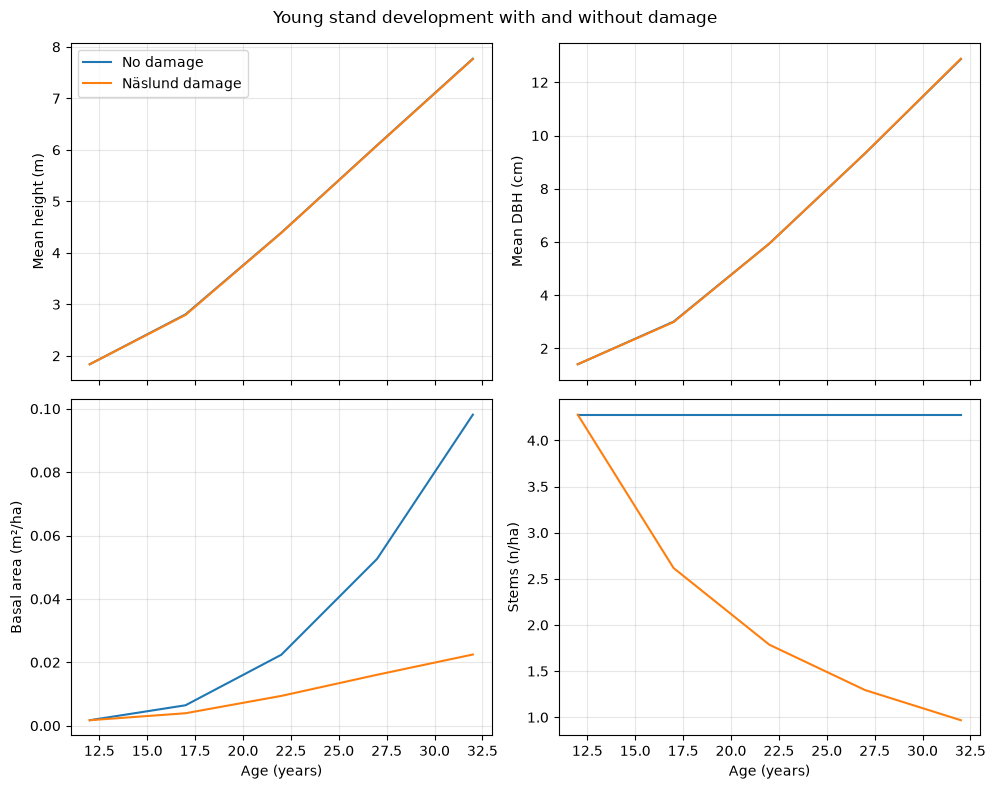

In [7]:
def plot_comparison(
    baseline: list[dict[str, float]],
    damaged: list[dict[str, float]],
) -> None:
    ages = [row["age_years"] for row in baseline]
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    axes = axes.flatten()

    metrics = [
        ("mean_height_m", "Mean height (m)"),
        ("mean_dbh_cm", "Mean DBH (cm)"),
        ("basal_area_m2_ha", "Basal area (m²/ha)"),
        ("stems_per_ha", "Stems (n/ha)"),
    ]

    for ax, (key, label) in zip(axes, metrics):
        ax.plot(ages, [row[key] for row in baseline], label="No damage")
        ax.plot(ages, [row[key] for row in damaged], label="Näslund damage")
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)

    axes[-2].set_xlabel("Age (years)")
    axes[-1].set_xlabel("Age (years)")
    axes[0].legend(loc="best")
    fig.suptitle("Young stand development with and without damage", fontsize=12)
    fig.tight_layout()


plot_comparison(baseline_results, damage_results)
